# k * RMSE Safety Stock Optimization

This notebook demonstrates the new `k_rmse` safety stock method with two policy-optimization flows:

- Optimize `k` to minimize total simulation cost.
- Optimize `k` subject to a fixed fill-rate target.


## Setup


In [13]:
from collections import defaultdict
from dataclasses import replace

import pandas as pd
import matplotlib.pyplot as plt

from replenishment import (
    InventoryState,
    PointForecastOptimizationPolicy,
    build_point_forecast_article_configs_from_standard_rows,
    build_replenishment_decisions_from_simulations,
    generate_standard_simulation_rows,
    optimize_k_rmse_factors,
    optimize_k_rmse_factors_for_fill_rate,
    plot_replenishment_decisions,
    replenishment_decision_rows_to_dataframe,
    simulate_replenishment_for_articles,
    split_standard_simulation_rows,
    standard_simulation_rows_to_dataframe,
)


### Parameters


In [14]:
review_period = 1
forecast_horizon = 1
rmse_window = 1

candidate_k = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
target_fill_rate = 0.95

# Optional: increase safety stock when forecasted demand is above a baseline.
demand_buffer_strength = 0.5
demand_buffer_reference = 20.0
demand_buffer_max_multiplier = 1.8


## Generate Data


In [15]:
rows = generate_standard_simulation_rows(
    n_unique_ids=1,
    periods=24,
    start_date="2031-01-01",
    frequency_days=30,
    forecast_start_period=14,
    history_mean=50,
    history_std=8,
    forecast_mean=48,
    forecast_std=7,
    lead_time=2,
    initial_on_hand=30,
    current_stock=30,
    holding_cost_per_unit=0.1,
    stockout_cost_per_unit=2.0,
    order_cost_per_order=0.0,
    seed=13,
)

backtest_rows, forecast_rows = split_standard_simulation_rows(rows)

backtest_actuals = defaultdict(list)
for row in backtest_rows:
    backtest_actuals[row.unique_id].append(int(row.actuals))

rows_df = standard_simulation_rows_to_dataframe(rows, library="pandas")
rows_df.head()


,unique_id,ds,forecast,actuals,holding_cost_per_unit,stockout_cost_per_unit,order_cost_per_order,lead_time,initial_on_hand,current_stock,is_forecast,forecast_p50,forecast_p90
0,A,2031-01-01,47,62.0,0.1,2.0,0.0,2,30,30,False,47,59
1,A,2031-01-31,43,36.0,0.1,2.0,0.0,2,30,30,False,43,54
2,A,2031-03-02,50,55.0,0.1,2.0,0.0,2,30,30,False,50,62
3,A,2031-04-01,51,55.0,0.1,2.0,0.0,2,30,30,False,51,64
4,A,2031-05-01,48,46.0,0.1,2.0,0.0,2,30,30,False,48,60


## 1) Optimize `k` for Minimum Total Cost


In [16]:
backtest_configs = build_point_forecast_article_configs_from_standard_rows(
    backtest_rows,
    service_level_factor=1.0,
    review_period=review_period,
    forecast_horizon=forecast_horizon,
    rmse_window=rmse_window,
    safety_stock_method="k_rmse",
)

optimized_cost = optimize_k_rmse_factors(backtest_configs, candidate_k=candidate_k)

cost_summary = pd.DataFrame(
    [
        {
            "unique_id": uid,
            "k": result.service_level_factor,
            "backtest_fill_rate": result.simulation.summary.fill_rate,
            "backtest_total_cost": result.simulation.summary.total_cost,
        }
        for uid, result in optimized_cost.items()
    ]
).sort_values("unique_id")

cost_summary


,unique_id,k,backtest_fill_rate,backtest_total_cost
0,A,4.0,0.780939,311.9


In [17]:
k_by_article = {uid: result.service_level_factor for uid, result in optimized_cost.items()}

forecast_configs_cost = build_point_forecast_article_configs_from_standard_rows(
    forecast_rows,
    service_level_factor=k_by_article,
    review_period=review_period,
    forecast_horizon=forecast_horizon,
    rmse_window=rmse_window,
    safety_stock_method="k_rmse",
    use_current_stock=True,
    actuals_override=backtest_actuals,
)
forecast_sims_cost = simulate_replenishment_for_articles(forecast_configs_cost)

decision_rows_cost = build_replenishment_decisions_from_simulations(
    forecast_rows,
    forecast_sims_cost,
    sigma=k_by_article,
    service_level_mode="factor",
)
decision_df_cost = replenishment_decision_rows_to_dataframe(decision_rows_cost, library="pandas")
decision_df_cost.head()


,unique_id,ds,quantity,demand,forecast_quantity,forecast_quantity_lead_time,reorder_point,order_up_to,incoming_stock,starting_stock,...,current_stock,on_order,backorders,missed_sales,sigma,aggregation_window,review_period,forecast_horizon,rmse_window,percentile_target
0,A,2032-02-25,41,36,36,41,85.0,121.0,0,30,...,0,41,0,6,4.0,1,1,1,1,None
1,A,2032-03-26,108,49,49,45,90.0,139.0,0,0,...,0,149,0,49,4.0,1,1,1,1,None
2,A,2032-04-25,18,41,41,43,86.0,127.0,41,41,...,0,126,0,0,4.0,1,1,1,1,None
3,A,2032-05-25,48,45,45,54,88.0,133.0,108,108,...,63,66,0,0,4.0,1,1,1,1,None
4,A,2032-06-24,29,43,43,47,97.0,140.0,18,81,...,38,77,0,0,4.0,1,1,1,1,None


<Axes: title={'center': 'k*RMSE Safety Stock (k optimized for minimum cost)'}, xlabel='Date', ylabel='Units'>

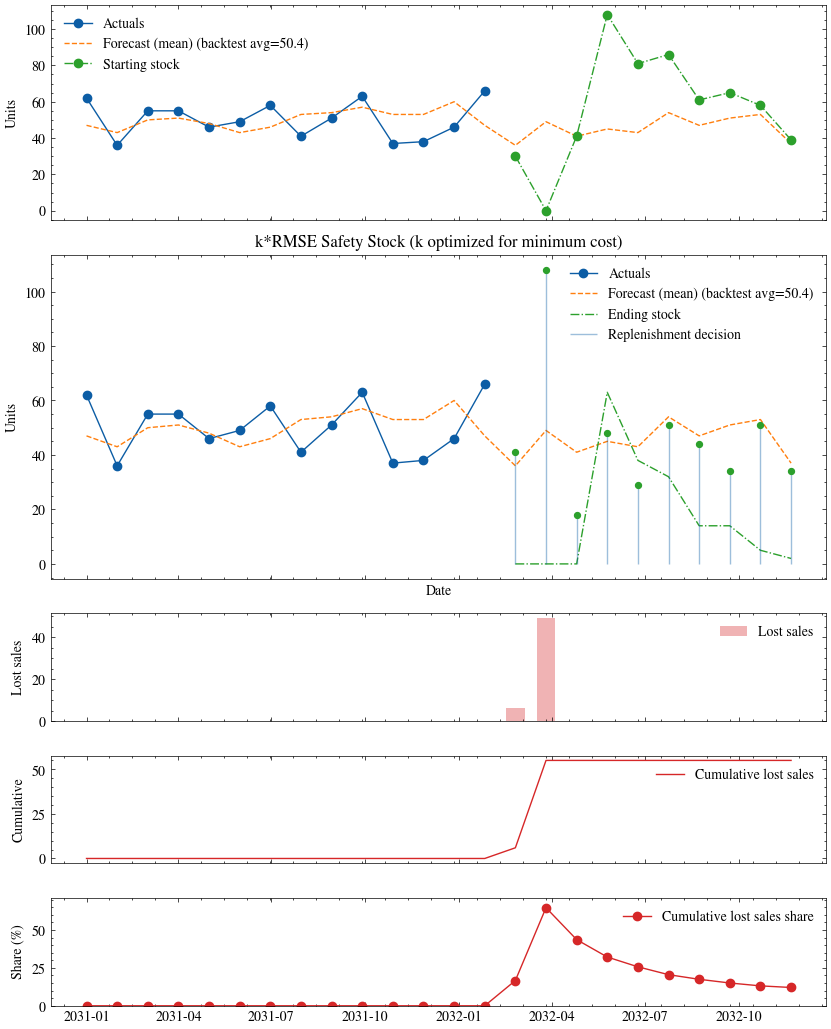

In [18]:
example_id = decision_df_cost["unique_id"].iloc[0]
plot_replenishment_decisions(
    rows_df,
    decision_df_cost,
    unique_id=example_id,
    title="k*RMSE Safety Stock (k optimized for minimum cost)",
    decision_style="line",
)


## 2) Optimize `k` with Fill-Rate Target


In [19]:
optimized_fill = optimize_k_rmse_factors_for_fill_rate(
    backtest_configs,
    candidate_k=candidate_k,
    target_fill_rate=target_fill_rate,
)

fill_summary = pd.DataFrame(
    [
        {
            "unique_id": uid,
            "k": result.k,
            "meets_fill_rate_target": result.meets_fill_rate_target,
            "achieved_fill_rate": result.achieved_fill_rate,
            "backtest_total_cost": result.simulation.summary.total_cost,
        }
        for uid, result in optimized_fill.items()
    ]
).sort_values("unique_id")

fill_summary


,unique_id,k,meets_fill_rate_target,achieved_fill_rate,backtest_total_cost
0,A,4.0,False,0.780939,311.9


In [20]:
fill_k_by_article = {uid: result.k for uid, result in optimized_fill.items()}

forecast_configs_fill = build_point_forecast_article_configs_from_standard_rows(
    forecast_rows,
    service_level_factor=fill_k_by_article,
    review_period=review_period,
    forecast_horizon=forecast_horizon,
    rmse_window=rmse_window,
    safety_stock_method="k_rmse",
    use_current_stock=True,
    actuals_override=backtest_actuals,
)
forecast_sims_fill = simulate_replenishment_for_articles(forecast_configs_fill)

decision_rows_fill = build_replenishment_decisions_from_simulations(
    forecast_rows,
    forecast_sims_fill,
    sigma=fill_k_by_article,
    service_level_mode="factor",
)
decision_df_fill = replenishment_decision_rows_to_dataframe(decision_rows_fill, library="pandas")
decision_df_fill.head()


,unique_id,ds,quantity,demand,forecast_quantity,forecast_quantity_lead_time,reorder_point,order_up_to,incoming_stock,starting_stock,...,current_stock,on_order,backorders,missed_sales,sigma,aggregation_window,review_period,forecast_horizon,rmse_window,percentile_target
0,A,2032-02-25,41,36,36,41,85.0,121.0,0,30,...,0,41,0,6,4.0,1,1,1,1,None
1,A,2032-03-26,108,49,49,45,90.0,139.0,0,0,...,0,149,0,49,4.0,1,1,1,1,None
2,A,2032-04-25,18,41,41,43,86.0,127.0,41,41,...,0,126,0,0,4.0,1,1,1,1,None
3,A,2032-05-25,48,45,45,54,88.0,133.0,108,108,...,63,66,0,0,4.0,1,1,1,1,None
4,A,2032-06-24,29,43,43,47,97.0,140.0,18,81,...,38,77,0,0,4.0,1,1,1,1,None


<Axes: title={'center': 'k*RMSE Safety Stock (target fill rate = 95%)'}, xlabel='Date', ylabel='Units'>

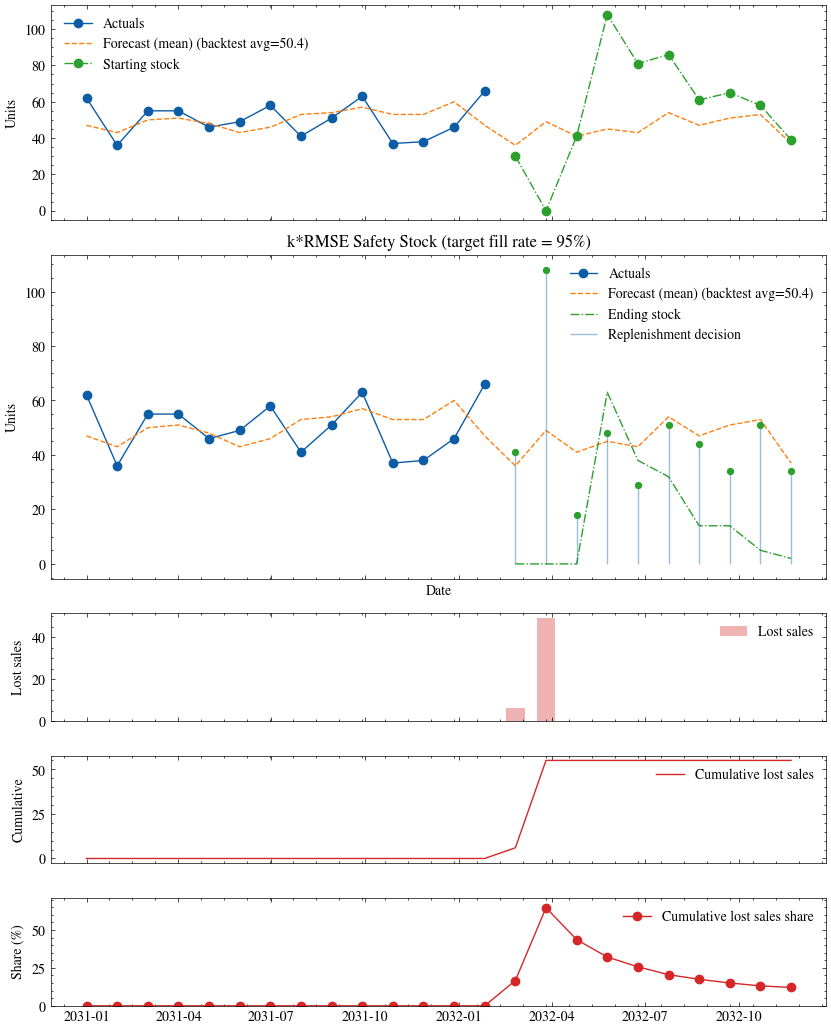

In [21]:
plot_replenishment_decisions(
    rows_df,
    decision_df_fill,
    unique_id=example_id,
    title=f"k*RMSE Safety Stock (target fill rate = {target_fill_rate:.0%})",
    decision_style="line",
)


## 3) Optional: Increase Safety Stock with Forecast Level

You can keep `k * RMSE` and also scale safety stock upward when forecasts rise by setting:

- `demand_buffer_strength`
- `demand_buffer_reference`
- `demand_buffer_max_multiplier`


In [22]:
forecast_configs_fill_buffered = {
    uid: replace(
        config,
        policy=replace(
            config.policy,
            demand_buffer_strength=demand_buffer_strength,
            demand_buffer_reference=demand_buffer_reference,
            demand_buffer_max_multiplier=demand_buffer_max_multiplier,
        ),
    )
    for uid, config in forecast_configs_fill.items()
}

forecast_sims_fill_buffered = simulate_replenishment_for_articles(
    forecast_configs_fill_buffered
)

buffered_summary = pd.DataFrame(
    [
        {
            "unique_id": uid,
            "k": fill_k_by_article[uid],
            "fill_rate_base": forecast_sims_fill[uid].summary.fill_rate,
            "fill_rate_buffered": sim.summary.fill_rate,
            "total_cost_base": forecast_sims_fill[uid].summary.total_cost,
            "total_cost_buffered": sim.summary.total_cost,
        }
        for uid, sim in forecast_sims_fill_buffered.items()
    ]
).sort_values("unique_id")

buffered_summary


,unique_id,k,fill_rate_base,fill_rate_buffered,total_cost_base,total_cost_buffered
0,A,4.0,0.879386,0.879386,126.8,160.1


In [23]:
def forecast_sum_with_carry_forward(values: list[int], start: int, horizon: int) -> int:
    return sum(values[idx] if idx < len(values) else values[-1] for idx in range(start, start + horizon))


state = InventoryState(period=1, on_hand=0, on_order=0, backorders=0)
scenario_forecasts = {
    "baseline_level": [10, 10, 10, 10, 10],
    "higher_forecast_level": [10, 10, 10, 20, 20],
}

buffer_demo_rows = []
for scenario, forecast_values in scenario_forecasts.items():
    for buffered in (False, True):
        policy = PointForecastOptimizationPolicy(
            forecast=forecast_values,
            actuals=[10, 10, 10, 10, 10],
            lead_time=1,
            forecast_horizon=2,
            service_level_factor=1.0,
            safety_stock_method="k_rmse",
            fixed_rmse=4.0,
            demand_buffer_strength=demand_buffer_strength if buffered else 0.0,
            demand_buffer_reference=demand_buffer_reference if buffered else None,
            demand_buffer_max_multiplier=demand_buffer_max_multiplier if buffered else None,
        )
        start_period = state.period + max(1, policy.lead_time)
        forecast_qty = forecast_sum_with_carry_forward(
            forecast_values,
            start_period,
            policy.forecast_horizon if policy.forecast_horizon is not None else 1,
        )
        order_qty = policy.order_quantity_for(state)
        buffer_demo_rows.append(
            {
                "scenario": scenario,
                "buffered": buffered,
                "forecast_quantity": forecast_qty,
                "order_quantity": order_qty,
                "implied_safety_stock": order_qty - forecast_qty,
            }
        )

buffer_demo_df = pd.DataFrame(buffer_demo_rows)
buffer_demo_df


,scenario,buffered,forecast_quantity,order_quantity,implied_safety_stock
0,baseline_level,False,20,24,4
1,baseline_level,True,20,24,4
2,higher_forecast_level,False,30,34,4
3,higher_forecast_level,True,30,35,5


### Plot: Replenishment Timelines for Rising Forecast Levels

Instead of a separate safety-stock panel, this view keeps the usual replenishment timeline and compares 3 articles with progressively steeper forecast ramps.
The shaded green band is the extra safety stock created by the forecast-level buffer, so you can see the higher target level and the larger replenishment decisions on the same time-series plot.


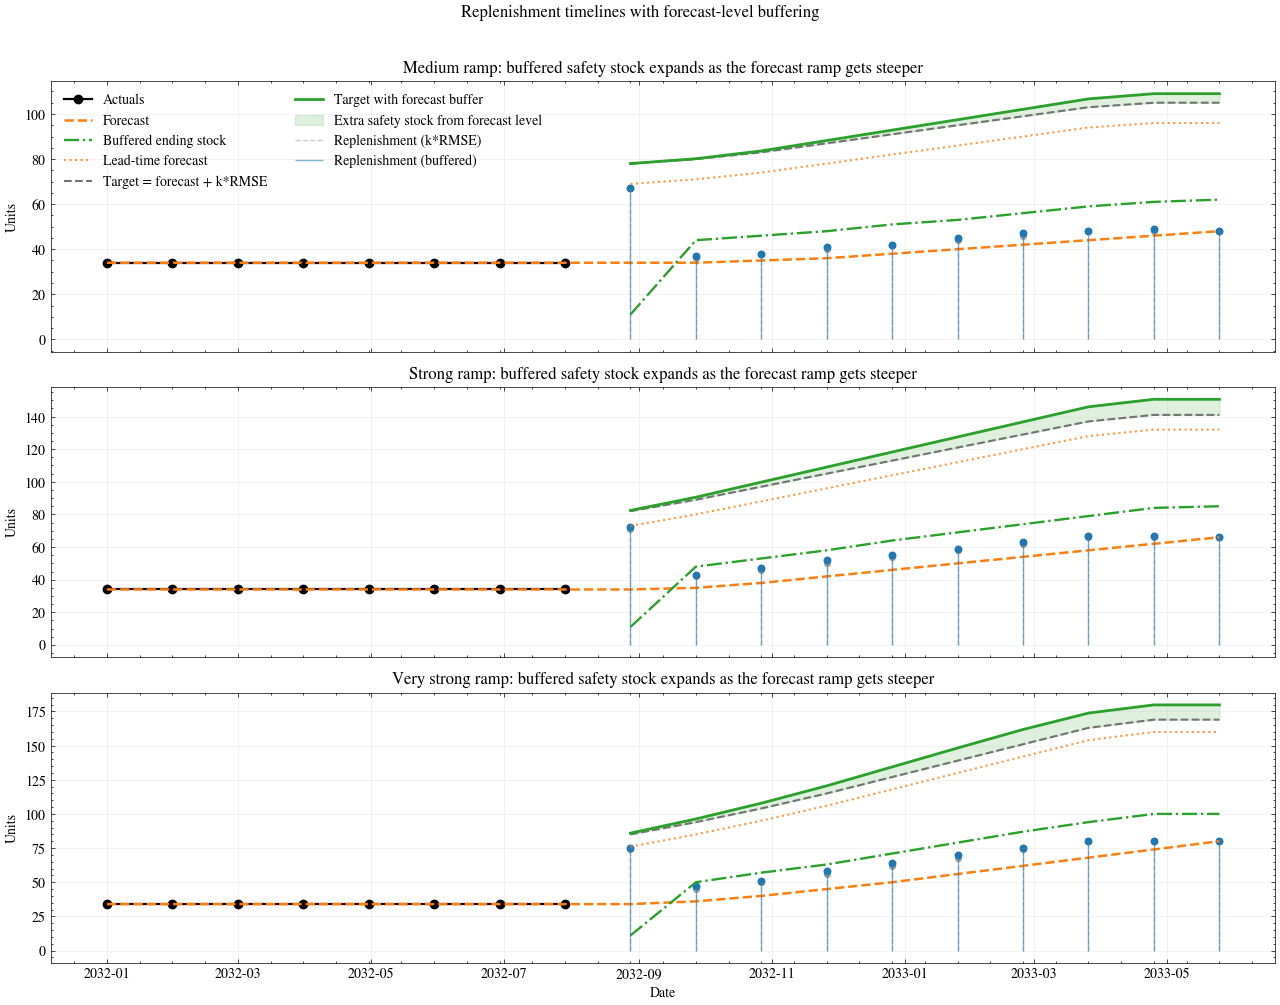

base_safety_stock      buffered_safety_stock             \
                                    min  max                   min        max   
unique_id                                                                       
uid_medium_trend                    9.0  9.0              9.000000  13.011429   
uid_strong_trend                    9.0  9.0              9.462857  18.565714   
uid_very_strong_trend               9.0  9.0              9.925714  19.800000   

                      extra_safety_stock             
                                     min        max  
unique_id                                            
uid_medium_trend                0.000000   4.011429  
uid_strong_trend                0.462857   9.565714  
uid_very_strong_trend           0.925714  10.800000

In [24]:
trend_demo_rows = generate_standard_simulation_rows(
    n_unique_ids=1,
    periods=18,
    start_date="2032-01-01",
    frequency_days=30,
    forecast_start_period=8,
    history_mean=34,
    history_std=0,
    forecast_mean=34,
    forecast_std=0,
    lead_time=1,
    initial_on_hand=45,
    current_stock=45,
    holding_cost_per_unit=0.1,
    stockout_cost_per_unit=2.0,
    order_cost_per_order=0.0,
    seed=7,
)

template_uid = trend_demo_rows[0].unique_id
trend_history_rows = [
    row for row in trend_demo_rows if row.unique_id == template_uid and not row.is_forecast
]
trend_forecast_rows = [
    row for row in trend_demo_rows if row.unique_id == template_uid and row.is_forecast
]
trend_actual_history = [int(row.actuals) for row in trend_history_rows]

trend_forecasts_by_uid = {
    "uid_medium_trend": [34, 34, 35, 36, 38, 40, 42, 44, 46, 48],
    "uid_strong_trend": [34, 35, 38, 42, 46, 50, 54, 58, 62, 66],
    "uid_very_strong_trend": [34, 36, 40, 45, 50, 56, 62, 68, 74, 80],
}
trend_labels = {
    "uid_medium_trend": "Medium ramp",
    "uid_strong_trend": "Strong ramp",
    "uid_very_strong_trend": "Very strong ramp",
}

trend_rows = []
trend_actuals_override = {}
for uid, forecast_values in trend_forecasts_by_uid.items():
    trend_actuals_override[uid] = trend_actual_history
    trend_rows.extend(replace(row, unique_id=uid) for row in trend_history_rows)
    trend_rows.extend(
        replace(row, unique_id=uid, forecast=forecast_value, demand=forecast_value)
        for row, forecast_value in zip(trend_forecast_rows, forecast_values, strict=True)
    )

trend_rows_df = standard_simulation_rows_to_dataframe(trend_rows, library="pandas")
trend_eval_rows = [row for row in trend_rows if row.is_forecast]

trend_demo_k = 1.5
trend_demo_fixed_rmse = 6.0
trend_demo_forecast_horizon = 2
trend_buffer_strength = 1.2
trend_buffer_reference = 70.0
trend_buffer_max_multiplier = 2.2

trend_configs_base = build_point_forecast_article_configs_from_standard_rows(
    trend_eval_rows,
    service_level_factor=trend_demo_k,
    review_period=1,
    forecast_horizon=trend_demo_forecast_horizon,
    rmse_window=1,
    safety_stock_method="k_rmse",
    fixed_rmse=trend_demo_fixed_rmse,
    use_current_stock=True,
    actuals_override=trend_actuals_override,
)
trend_configs_buffered = {
    uid: replace(
        config,
        policy=replace(
            config.policy,
            demand_buffer_strength=trend_buffer_strength,
            demand_buffer_reference=trend_buffer_reference,
            demand_buffer_max_multiplier=trend_buffer_max_multiplier,
        ),
    )
    for uid, config in trend_configs_base.items()
}

trend_sims_base = simulate_replenishment_for_articles(trend_configs_base)
trend_sims_buffered = simulate_replenishment_for_articles(trend_configs_buffered)

trend_decision_df_base = replenishment_decision_rows_to_dataframe(
    build_replenishment_decisions_from_simulations(
        trend_eval_rows,
        trend_sims_base,
        sigma=trend_demo_k,
        fixed_rmse=trend_demo_fixed_rmse,
        service_level_mode="factor",
        forecast_horizon=trend_demo_forecast_horizon,
        rmse_window=1,
        review_period=1,
    ),
    library="pandas",
)
trend_decision_df_buffered = replenishment_decision_rows_to_dataframe(
    build_replenishment_decisions_from_simulations(
        trend_eval_rows,
        trend_sims_buffered,
        sigma=trend_demo_k,
        fixed_rmse=trend_demo_fixed_rmse,
        service_level_mode="factor",
        forecast_horizon=trend_demo_forecast_horizon,
        rmse_window=1,
        review_period=1,
    ),
    library="pandas",
)


def demand_buffer_multiplier(
    forecast_qty: float,
    reference_qty: float | None,
    strength: float,
    max_multiplier: float | None,
) -> float:
    if strength <= 0 or forecast_qty <= 0 or reference_qty is None or reference_qty <= 0:
        return 1.0
    uplift = max(0.0, (forecast_qty / reference_qty) - 1.0)
    multiplier = 1.0 + (strength * uplift)
    if max_multiplier is not None:
        multiplier = min(multiplier, max_multiplier)
    return max(1.0, multiplier)


base_safety_stock = trend_demo_k * trend_demo_fixed_rmse
trend_plot_rows = []
for uid, forecast_values in trend_forecasts_by_uid.items():
    for period in range(len(forecast_values)):
        lead_time_forecast = forecast_sum_with_carry_forward(
            forecast_values,
            period + 1,
            trend_demo_forecast_horizon,
        )
        buffered_multiplier = demand_buffer_multiplier(
            lead_time_forecast,
            trend_buffer_reference,
            trend_buffer_strength,
            trend_buffer_max_multiplier,
        )
        buffered_safety_stock = base_safety_stock * buffered_multiplier
        trend_plot_rows.append(
            {
                "unique_id": uid,
                "period": period,
                "lead_time_forecast": lead_time_forecast,
                "base_safety_stock": base_safety_stock,
                "buffered_safety_stock": buffered_safety_stock,
                "base_target": lead_time_forecast + base_safety_stock,
                "buffered_target": lead_time_forecast + buffered_safety_stock,
            }
        )

trend_plot_df = pd.DataFrame(trend_plot_rows).merge(
    trend_decision_df_buffered[["unique_id", "ds"]].assign(
        period=lambda frame: frame.groupby("unique_id").cumcount()
    ),
    on=["unique_id", "period"],
    how="left",
)
trend_plot_df["ds"] = pd.to_datetime(trend_plot_df["ds"])

trend_demo_summary = (
    trend_plot_df.assign(
        extra_safety_stock=lambda frame: frame["buffered_safety_stock"]
        - frame["base_safety_stock"]
    )
    .groupby("unique_id")[[
        "base_safety_stock",
        "buffered_safety_stock",
        "extra_safety_stock",
    ]]
    .agg(["min", "max"])
)

fig, axes = plt.subplots(len(trend_forecasts_by_uid), 1, figsize=(13, 10), sharex=True)
if len(trend_forecasts_by_uid) == 1:
    axes = [axes]

for axis, uid in zip(axes, trend_forecasts_by_uid, strict=True):
    row_group = trend_rows_df.loc[trend_rows_df["unique_id"] == uid].copy()
    row_group["ds"] = pd.to_datetime(row_group["ds"])
    row_group = row_group.sort_values("ds")

    base_group = trend_decision_df_base.loc[
        trend_decision_df_base["unique_id"] == uid
    ].copy()
    base_group["ds"] = pd.to_datetime(base_group["ds"])
    base_group = base_group.sort_values("ds")

    buffered_group = trend_decision_df_buffered.loc[
        trend_decision_df_buffered["unique_id"] == uid
    ].copy()
    buffered_group["ds"] = pd.to_datetime(buffered_group["ds"])
    buffered_group = buffered_group.sort_values("ds")

    plot_group = trend_plot_df.loc[trend_plot_df["unique_id"] == uid].copy()
    plot_group = plot_group.sort_values("ds")

    axis.plot(
        row_group["ds"],
        row_group["actuals"],
        color="black",
        marker="o",
        linewidth=1.6,
        label="Actuals",
    )
    axis.plot(
        row_group["ds"],
        row_group["forecast"],
        color="tab:orange",
        linestyle="--",
        linewidth=1.8,
        label="Forecast",
    )
    axis.plot(
        buffered_group["ds"],
        buffered_group["ending_stock"],
        color="tab:green",
        linestyle="-.",
        linewidth=1.7,
        label="Buffered ending stock",
    )
    axis.plot(
        plot_group["ds"],
        plot_group["lead_time_forecast"],
        color="tab:orange",
        linestyle=":",
        linewidth=1.5,
        alpha=0.8,
        label="Lead-time forecast",
    )
    axis.plot(
        plot_group["ds"],
        plot_group["base_target"],
        color="0.45",
        linestyle="--",
        linewidth=1.5,
        label="Target = forecast + k*RMSE",
    )
    axis.plot(
        plot_group["ds"],
        plot_group["buffered_target"],
        color="tab:green",
        linewidth=2.0,
        label="Target with forecast buffer",
    )
    axis.fill_between(
        plot_group["ds"],
        plot_group["base_target"],
        plot_group["buffered_target"],
        color="tab:green",
        alpha=0.15,
        label="Extra safety stock from forecast level",
    )
    axis.vlines(
        base_group["ds"],
        0,
        base_group["quantity"],
        color="0.55",
        linestyle="--",
        alpha=0.45,
        label="Replenishment (k*RMSE)",
    )
    axis.scatter(
        base_group["ds"],
        base_group["quantity"],
        color="0.55",
        s=18,
        alpha=0.7,
    )
    axis.vlines(
        buffered_group["ds"],
        0,
        buffered_group["quantity"],
        color="tab:blue",
        alpha=0.55,
        label="Replenishment (buffered)",
    )
    axis.scatter(
        buffered_group["ds"],
        buffered_group["quantity"],
        color="tab:blue",
        s=22,
    )
    axis.set_title(
        f"{trend_labels[uid]}: buffered safety stock expands as the forecast ramp gets steeper"
    )
    axis.set_ylabel("Units")
    axis.grid(alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, loc="upper left", ncol=2)
axes[-1].set_xlabel("Date")
fig.suptitle("Replenishment timelines with forecast-level buffering", y=1.01)
plt.tight_layout()
plt.show()

trend_demo_summary


## Notes

- Old behavior is still available via `safety_stock_method="sqrt_horizon"`.
- This notebook intentionally uses `safety_stock_method="k_rmse"` to apply raw `k * RMSE`.
- Set `demand_buffer_strength > 0` to increase safety stock when forecast quantities are above a reference level.
